# Lesson 7: Cross-Validation

## Objective
- Nfhmou Cross-Validation (CV) w 3lach howa mohim f ML
- Nfhmou kifch nkhayro alpha w n9aymou model b CV
- Kifech n'evitou data leakage m3a CV

| Part       | Role                |
| ---------- | -------------------- |
| Train      | Yt3lm               |
| Validation | Nkhtaro model + alpha |
| Test       | Eval Finale        |


## Intuition

Cross-Validation tkhalina nkhtaro model w hyperparameters bla ma nkhrbou f test data

- Nkhtarou bel Validation
- N9aymou bel Test mara wa7da f l'akhir

Hnaya sta3melna K-Fold Cross-Validation 7it hiya l'akthar est3malan f l'industrie dyal ML

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

## Dataset

We use the same house price dataset to keep comparisons fair

In [19]:
# X = np.array([40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
# y = np.array([78, 102, 118, 145, 158, 182, 205])

X = np.linspace(40, 100, 30).reshape(-1, 1)
y = 2 * X.flatten() + np.random.normal(0, 10, size=30)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [26]:
alphas = [0.01, 0.1, 1, 10, 100, 10000, 989954984]
kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_errors = []

for alpha in alphas:
    fold_errors = []

    for train_idx, val_idx in kf.split(X_train_poly):
        X_tr, X_val = X_train_poly[train_idx], X_train_poly[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)

        y_val_pred = model.predict(X_val)
        fold_errors.append(mean_squared_error(y_val, y_val_pred))

    cv_errors.append(np.mean(fold_errors))


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.10626e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.56244e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.08858e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.00745e-42): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.61497e-42): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

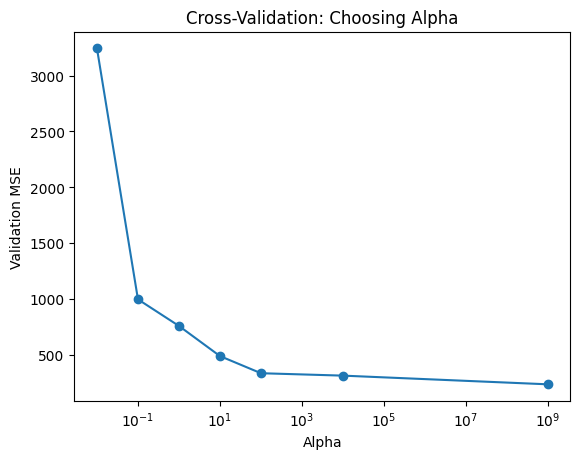

In [27]:
plt.plot(alphas, cv_errors, marker='o')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Validation MSE")
plt.title("Cross-Validation: Choosing Alpha")
plt.show()

In [28]:
best_alpha = alphas[np.argmin(cv_errors)]
print("Best alpha:", best_alpha)

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_poly, y_train)

y_test_pred = final_model.predict(X_test_poly)

print("Final Test MSE:",
      mean_squared_error(y_test, y_test_pred))

Best alpha: 989954984
Final Test MSE: 130.90242017999321


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.41287e-32): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


CROSS VALIDATION MA KTKHDMCH MZYAN YLA KEN 3NDNA DATASET SGHIR BZAF W LA VARIATION DYAL ALPHA M3NDHA TA3TIR KBEER 3LA RESULTAT